# Datathon Fase 5

Base de dados: https://cfpb.github.io

In [ ]:
#!pip install transformers datasets accele

# Resolução

## Imports




In [ ]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Baixando os léxicos e pacotes do NLTK (necessário rodar apenas uma vez)
nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

## Database

In [ ]:
import requests
import pandas as pd
import io

url = "https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/"
headers = {'User-Agent': 'Mozilla/5.0', 'Accept': 'text/csv'}

params = {
    'size': 1000, #
    'has_narrative': 'true',
    'format': 'csv',
    'date_received_min': '2025-01-12',
    'date_received_max': '2025-02-11'
}

try:
    response = requests.get(url, params=params, headers=headers, timeout=30)
    response.raise_for_status()

    #Lendo o CSV sem filtrar colunas ainda
    df = pd.read_csv(io.StringIO(response.text))


    # LISTAR AS COLUNAS DA BASE
    print("Nomes das colunas encontrados na API:")
    print(df.columns.tolist())

    # MOSTRAR AS PRIMEIRAS LINHAS IDENTIFICAR O TEXTO
    print("\nVisualização dos dados:")
    display(df.head())

except Exception as e:
    print(f"Erro: {e}")



Nomes das colunas encontrados na API:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

Visualização dos dados:


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,01/23/25,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Investigation took more than 30 days,The company inaccurately reported my data. Thi...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,IA,503XX,NaN,Consent provided,Web,01/23/25,Closed with explanation,Yes,NaN,11713011
1,01/24/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"This CFPB complaint has been filed to request,...",Company has responded to the consumer and the ...,Experian Information Solutions Inc.,TX,75241,NaN,Consent provided,Web,01/24/25,Closed with explanation,Yes,NaN,11772093
2,01/29/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,I have several inaccurate payment statuses bet...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",MD,20743,Servicemember,Consent provided,Web,01/29/25,Closed with explanation,Yes,NaN,11830114
3,01/17/25,"Money transfer, virtual currency, or money ser...",Domestic (US) money transfer,Other transaction problem,NaN,I am filing a complaint against Cash App ( Blo...,NaN,"Block, Inc.",TX,77045,NaN,Consent provided,Web,01/18/25,Closed with explanation,Yes,NaN,11663916
4,01/31/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,*15 USC 1681c-2 ( a ) ** : This statute requir...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,IL,608XX,NaN,Consent provided,Web,01/31/25,Closed with explanation,Yes,NaN,11881850


## Análise Exploratória de Dados (EDA)

In [ ]:
df.shape

(178877, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178877 entries, 0 to 178876
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Date received                 178877 non-null  object 
 1   Product                       178877 non-null  object 
 2   Sub-product                   178877 non-null  object 
 3   Issue                         178877 non-null  object 
 4   Sub-issue                     133393 non-null  object 
 5   Consumer complaint narrative  178877 non-null  object 
 6   Company public response       78794 non-null   object 
 7   Company                       178877 non-null  object 
 8   State                         178153 non-null  object 
 9   ZIP code                      178877 non-null  object 
 10  Tags                          12843 non-null   object 
 11  Consumer consent provided?    178877 non-null  object 
 12  Submitted via                 178877 non-nul

### PASSO 1: Limpeza inicial e Missing Values

In [ ]:
# 1.1 removendo linhas duplicadas a partir da coluna Consumer complaint narrative

df = df.drop_duplicates(subset=['Consumer complaint narrative'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102708 entries, 0 to 178875
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Date received                 102708 non-null  datetime64[ns]
 1   Product                       102708 non-null  object        
 2   Sub-product                   102708 non-null  object        
 3   Issue                         102708 non-null  object        
 4   Sub-issue                     79856 non-null   object        
 5   Consumer complaint narrative  102708 non-null  object        
 6   Company public response       44174 non-null   object        
 7   Company                       102708 non-null  object        
 8   State                         102490 non-null  object        
 9   ZIP code                      102708 non-null  object        
 10  Tags                          10072 non-null   object        
 11  Consumer consent p

Com a remoção da duplicacao dos dados da coluna de reclamação foi possível remover ~80k linhas

In [ ]:
# 1.2 Tratamento de dados ausentes (Fazer isso antes da limpeza do texto evita erros)
df = df.dropna(subset=['Consumer complaint narrative'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102708 entries, 0 to 178875
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Date received                 102708 non-null  datetime64[ns]
 1   Product                       102708 non-null  object        
 2   Sub-product                   102708 non-null  object        
 3   Issue                         102708 non-null  object        
 4   Sub-issue                     79856 non-null   object        
 5   Consumer complaint narrative  102708 non-null  object        
 6   Company public response       44174 non-null   object        
 7   Company                       102708 non-null  object        
 8   State                         102490 non-null  object        
 9   ZIP code                      102708 non-null  object        
 10  Tags                          10072 non-null   object        
 11  Consumer consent p

Não havia nenhuma linha nula

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102708 entries, 0 to 178875
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Date received                 102708 non-null  datetime64[ns]
 1   Product                       102708 non-null  object        
 2   Sub-product                   102708 non-null  object        
 3   Issue                         102708 non-null  object        
 4   Sub-issue                     79856 non-null   object        
 5   Consumer complaint narrative  102708 non-null  object        
 6   Company public response       44174 non-null   object        
 7   Company                       102708 non-null  object        
 8   State                         102490 non-null  object        
 9   ZIP code                      102708 non-null  object        
 10  Tags                          10072 non-null   object        
 11  Consumer consent p

### PASSO 2: Normalização de Texto

In [ ]:
# 2.1 Limpeza básica e Normalização da coluna de reclamações para ficar melhor de identificar valores

def clean_and_normalize(text):
    text = str(text)
    # Normalização: Converter para minúsculas
    text = text.lower()
    # Limpeza: Remover a máscara de anonimização 'xxxx'
    text = re.sub(r'x+', '', text)
    # Limpeza: Remover números (códigos de leis, valores, etc)
    text = re.sub(r'\d+', '', text)
    # Limpeza: Remover pontuações extras e espaços duplicados
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['Consumer complaint narrative'].apply(clean_and_normalize)

In [ ]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,clean_text
0,01/23/25,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Investigation took more than 30 days,The company inaccurately reported my data. Thi...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,IA,503XX,NaN,Consent provided,Web,01/23/25,Closed with explanation,Yes,NaN,11713011,the company inaccurately reported my data this...
1,01/24/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"This CFPB complaint has been filed to request,...",Company has responded to the consumer and the ...,Experian Information Solutions Inc.,TX,75241,NaN,Consent provided,Web,01/24/25,Closed with explanation,Yes,NaN,11772093,this cfpb complaint has been filed to request ...
2,01/29/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,I have several inaccurate payment statuses bet...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",MD,20743,Servicemember,Consent provided,Web,01/29/25,Closed with explanation,Yes,NaN,11830114,i have several inaccurate payment statuses bet...
3,01/17/25,"Money transfer, virtual currency, or money ser...",Domestic (US) money transfer,Other transaction problem,NaN,I am filing a complaint against Cash App ( Blo...,NaN,"Block, Inc.",TX,77045,NaN,Consent provided,Web,01/18/25,Closed with explanation,Yes,NaN,11663916,i am filing a complaint against cash app block...
4,01/31/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,*15 USC 1681c-2 ( a ) ** : This statute requir...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,IL,608XX,NaN,Consent provided,Web,01/31/25,Closed with explanation,Yes,NaN,11881850,usc c a this statute requires consumer reporti...


In [ ]:
# Tokenizacao dos dados limpos
from nltk.stem import WordNetLemmatizer
# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()
# Function to clean, tokenize, remove stopwords, and lemmatize text
def clean_and_lemmatize(text):
    #text = text.lower()  # Convert to lowercase
    tokens = word_tokenize(text)  # Tokenization
    tokens = [word for word in tokens if word.isalpha()]  # Remove punctuation and numbers

    stop_words = set(stopwords.words('english'))  # Load stopwords
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords

    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Lemmatization
    return lemmatized_tokens

# Apply the updated cleaning function
df["cleaned_text"] = df["clean_text"].apply(clean_and_lemmatize)

### PASSO 3: Análise de desequilíbrio de classes (Variáveis Categóricas)

In [ ]:
def plot_categorical_dist(df, column, title):
    plt.figure(figsize=(12, 6))
    # Calculando a porcentagem para mostrar o desequilíbrio real
    counts = df[column].value_counts(normalize=True) * 100
    sns.barplot(x=counts.values, y=counts.index, palette='viridis')

    plt.title(f'Distribuição Percetual: {title}')
    plt.xlabel('Porcentagem do Dataset (%)')
    plt.ylabel(column)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

/tmp/ipykernel_7424/622259153.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


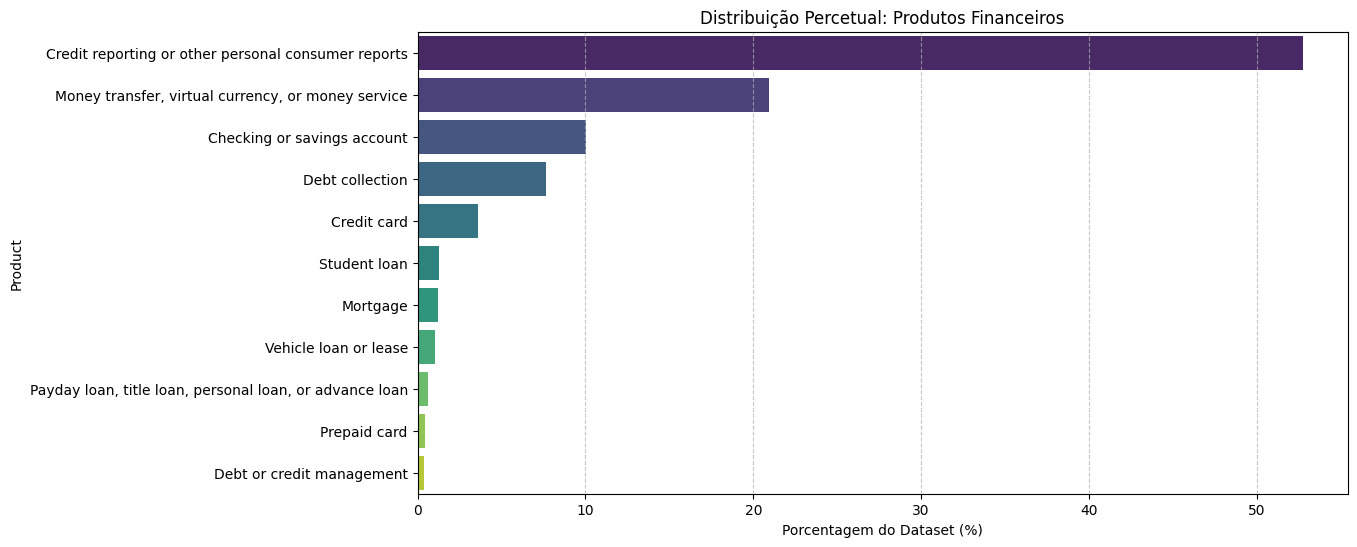

In [ ]:
# Analisando os Produtos Financeiros (Sua variável de categoria principal)
plot_categorical_dist(df, 'Product', 'Produtos Financeiros')

/tmp/ipykernel_7424/622259153.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


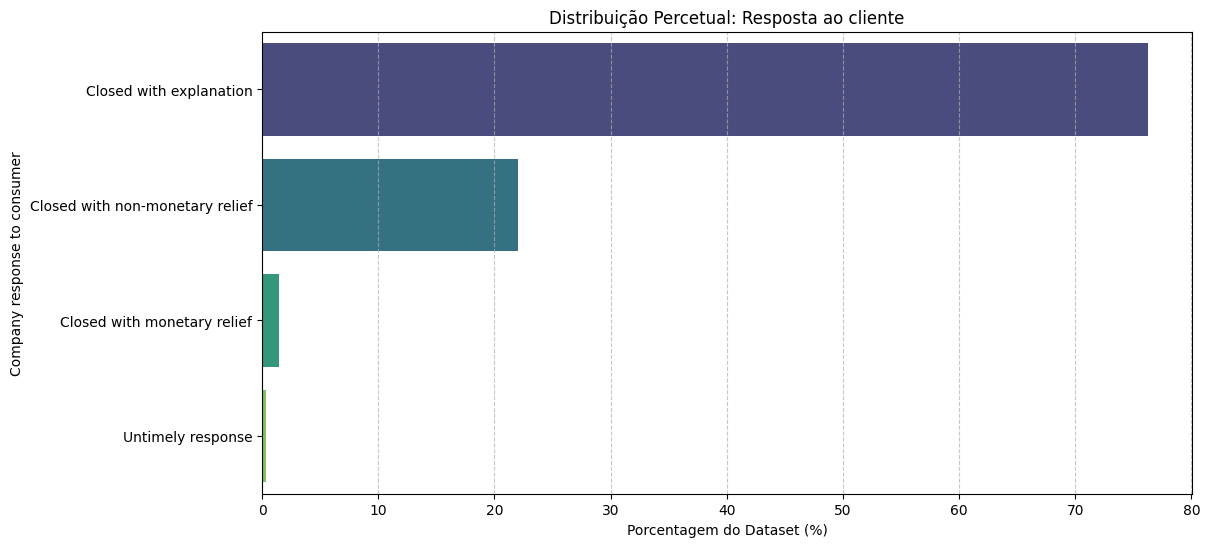

In [ ]:
# Analisando se Empresa respondeu ao cliente  (Company response to consumer)
plot_categorical_dist(df, 'Company response to consumer', 'Resposta ao cliente')

/tmp/ipykernel_7424/622259153.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


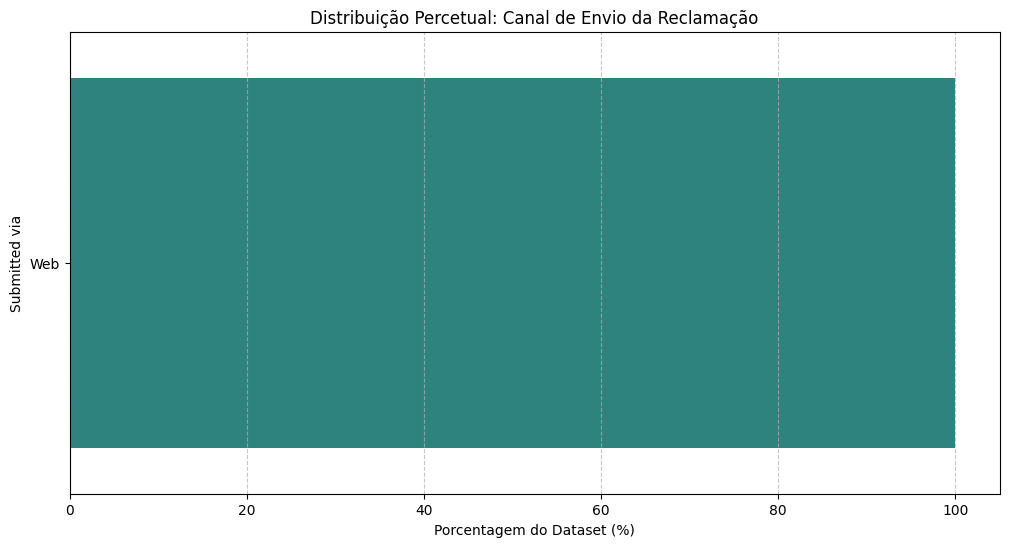

In [ ]:
# Analisando o Canal de Entrada()
plot_categorical_dist(df, 'Submitted via', 'Canal de Envio da Reclamação')

/tmp/ipykernel_7424/2998237533.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_issues.values, y=top_issues.index, palette="Reds_r")


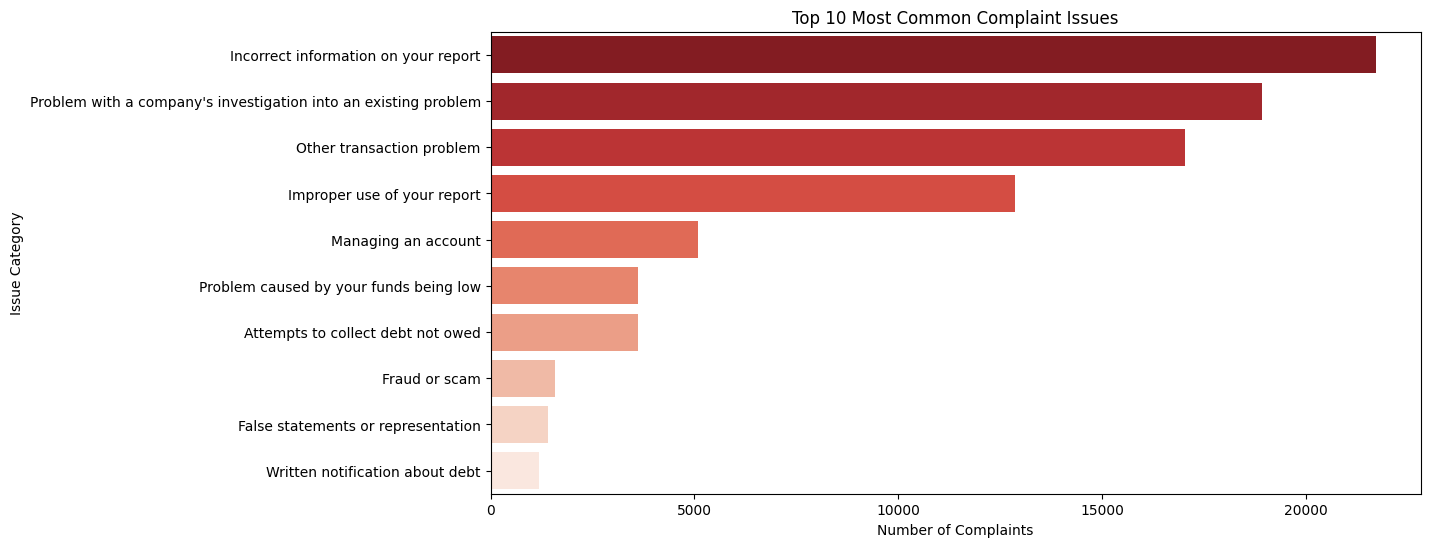

In [ ]:
# Analisando as 10 reclamações mais frequentes
# 🔹 Count the top 10 most common issues
top_issues = df['Issue'].value_counts().nlargest(10)

# 🔹 Plot the top 10 issues
plt.figure(figsize=(12, 6))
sns.barplot(x=top_issues.values, y=top_issues.index, palette="Reds_r")
plt.xlabel("Number of Complaints")
plt.ylabel("Issue Category")
plt.title("Top 10 Most Common Complaint Issues")
plt.show()

/tmp/ipykernel_7424/1101739990.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_issues.values, y=top_issues.index, palette="Reds_r")


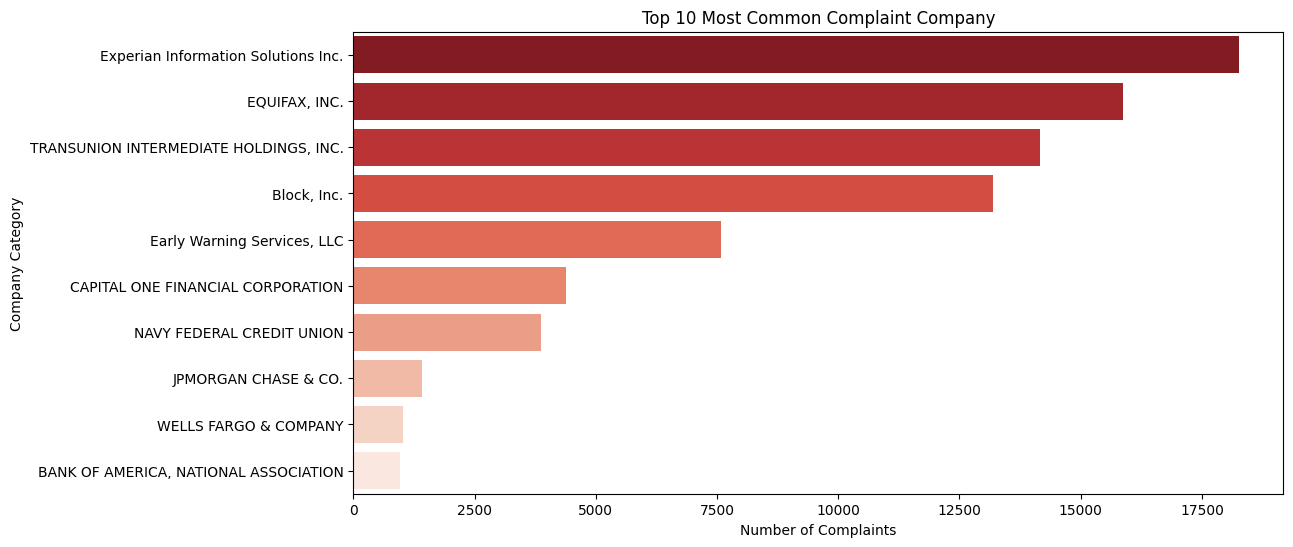

In [ ]:
# Analisando a Empresa que recebeu reclamacao
# 🔹 Count the top 10 most common company
top_issues = df['Company'].value_counts().nlargest(10)

# 🔹 Plot the top 10 issues
plt.figure(figsize=(12, 6))
sns.barplot(x=top_issues.values, y=top_issues.index, palette="Reds_r")
plt.xlabel("Number of Complaints")
plt.ylabel("Company Category")
plt.title("Top 10 Most Common Complaint Company")
plt.show()

/tmp/ipykernel_7424/622259153.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


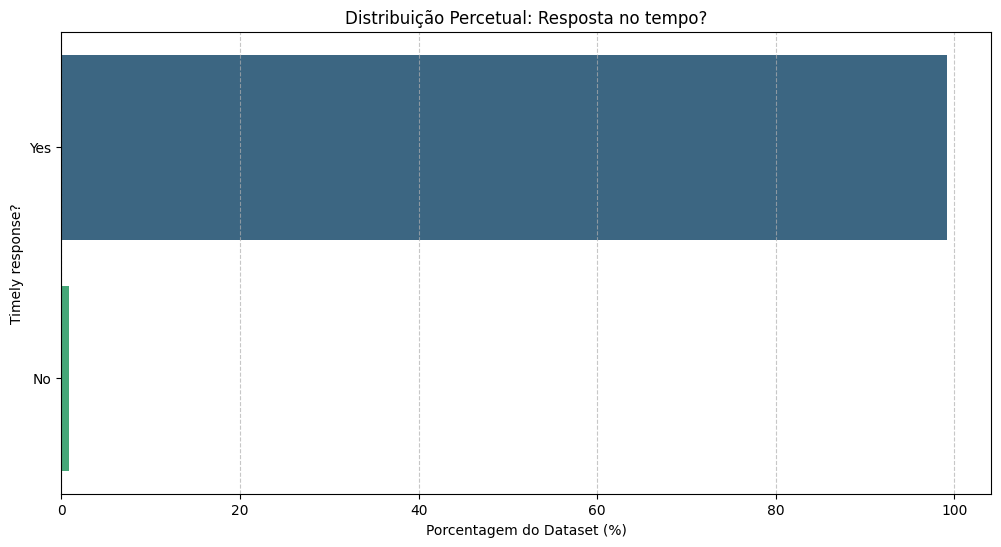

In [ ]:
# Analisando se a resposta foi dentro do prazo esperado
plot_categorical_dist(df, 'Timely response?', 'Resposta no tempo?')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102708 entries, 0 to 178875
Data columns (total 20 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Date received                 102708 non-null  object 
 1   Product                       102708 non-null  object 
 2   Sub-product                   102708 non-null  object 
 3   Issue                         102708 non-null  object 
 4   Sub-issue                     79856 non-null   object 
 5   Consumer complaint narrative  102708 non-null  object 
 6   Company public response       44174 non-null   object 
 7   Company                       102708 non-null  object 
 8   State                         102490 non-null  object 
 9   ZIP code                      102708 non-null  object 
 10  Tags                          10072 non-null   object 
 11  Consumer consent provided?    102708 non-null  object 
 12  Submitted via                 102708 non-null  ob

### PASSO 4: Análise Temporal

In [ ]:
df['Date received'] = pd.to_datetime(df['Date received'], format='%m/%d/%y')
df['Date sent to company'] = pd.to_datetime(df['Date sent to company'], format='%m/%d/%y')

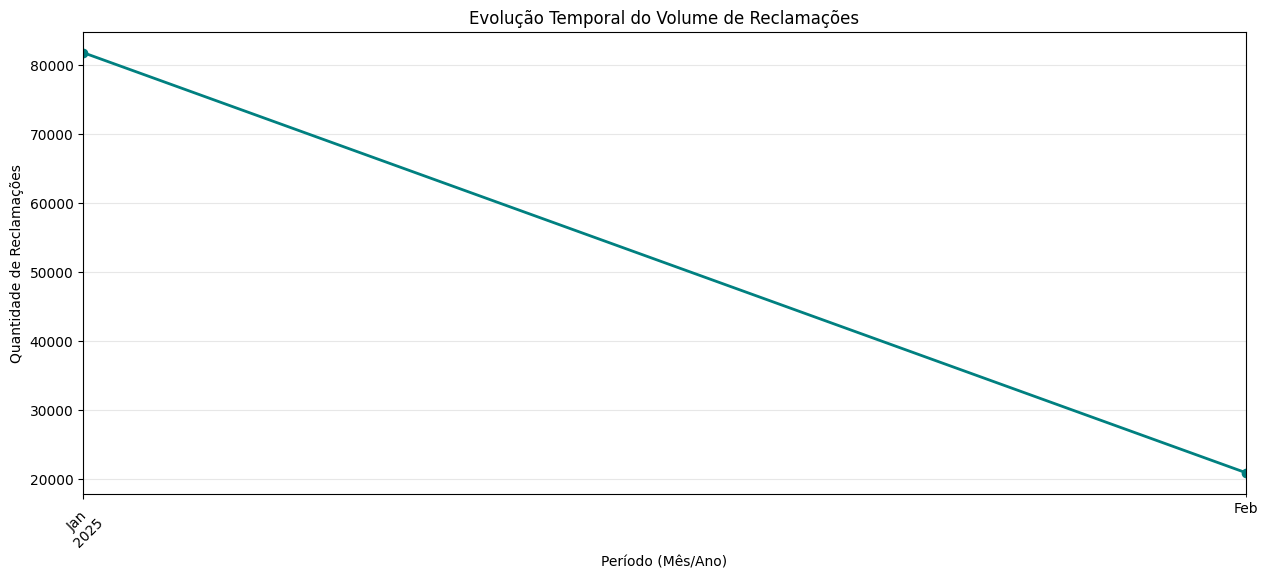

In [ ]:
# 4.1 Evolução Mensal de Reclamações
df['Month_Year'] = df['Date received'].dt.to_period('M')
temporal_dist = df.groupby('Month_Year').size()

plt.figure(figsize=(15, 6))
temporal_dist.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Evolução Temporal do Volume de Reclamações')
plt.xlabel('Período (Mês/Ano)')
plt.ylabel('Quantidade de Reclamações')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:

# 2. Criação de colunas auxiliares para facilitar a plotagem
df['Day_of_Week'] = df['Date received'].dt.day_name()

/tmp/ipykernel_7424/1201794197.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Day_of_Week', data=df, order=days_order, palette='magma')


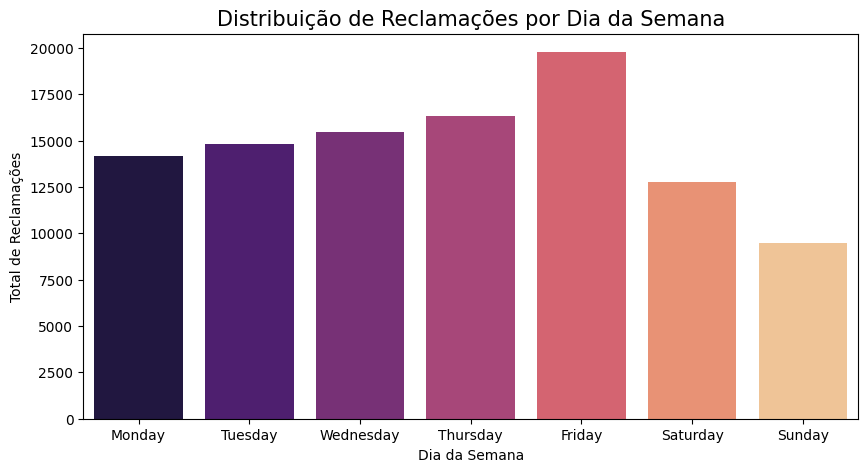

In [ ]:
# --- VISUALIZAÇÃO 2: Reclamações por Dia da Semana ---
# (Útil para entender o comportamento operacional das dores dos clientes)
plt.figure(figsize=(10, 5))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x='Day_of_Week', data=df, order=days_order, palette='magma')

plt.title('Distribuição de Reclamações por Dia da Semana', fontsize=15)
plt.xlabel('Dia da Semana')
plt.ylabel('Total de Reclamações')
plt.show()

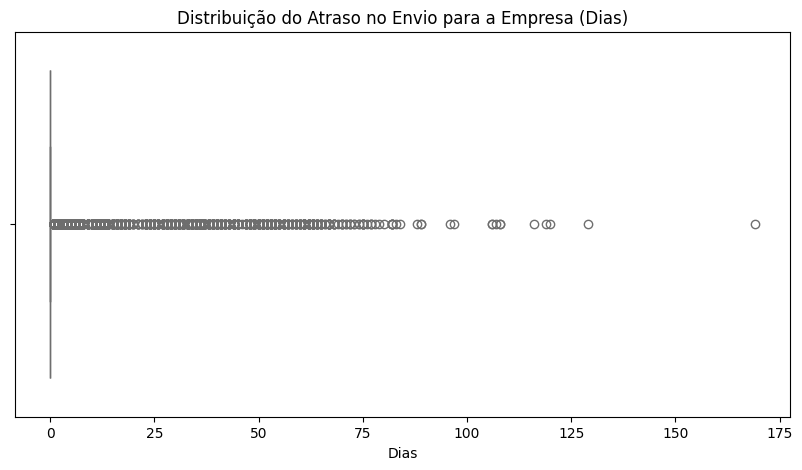

In [ ]:
# 4.2 Tempo de Resposta (Diferença entre recebimento e envio à empresa)
df['Days_to_Send'] = (df['Date sent to company'] - df['Date received']).dt.days

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Days_to_Send'], color='lightcoral')
plt.title('Distribuição do Atraso no Envio para a Empresa (Dias)')
plt.xlabel('Dias')
plt.show()

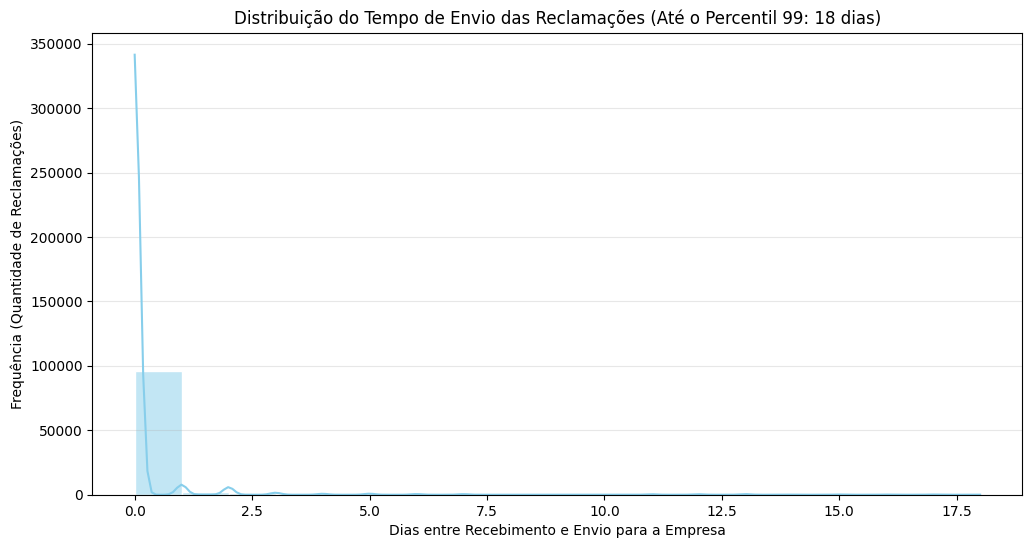

In [ ]:
# 1. Definir um limite para remover os valores extremos (ex: 99% dos dados)
# Isso evita que o gráfico fique com um espaço vazio gigante na direita
limite_99 = df['Days_to_Send'].quantile(0.99)
# df_filtrado = df[df['Days_to_Send'] <= limite_99]

# 2. Criar o Histograma
plt.figure(figsize=(12, 6))
sns.histplot(df[df['Days_to_Send'] <= limite_99]['Days_to_Send'],
             bins=int(limite_99) if limite_99 > 0 else 10, # Um bin para cada dia
             kde=True,
             color='skyblue',
             edgecolor='white')

# 3. Customização do gráfico
plt.title(f'Distribuição do Tempo de Envio das Reclamações (Até o Percentil 99: {limite_99:.0f} dias)')
plt.xlabel('Dias entre Recebimento e Envio para a Empresa')
plt.ylabel('Frequência (Quantidade de Reclamações)')
plt.grid(axis='y', alpha=0.3)

plt.show()

Praticamente todas as respostas são realizadas no mesmo dia que a reclamação é feita

In [ ]:
# Calcula a proporção e multiplica por 100 para ter a porcentagem
porcentagem_zero_dias = (df['Days_to_Send'] == 0).mean() * 100

print(f"{porcentagem_zero_dias:.2f}% das reclamações foram enviadas no mesmo dia.")

93.58% das reclamações foram enviadas no mesmo dia.


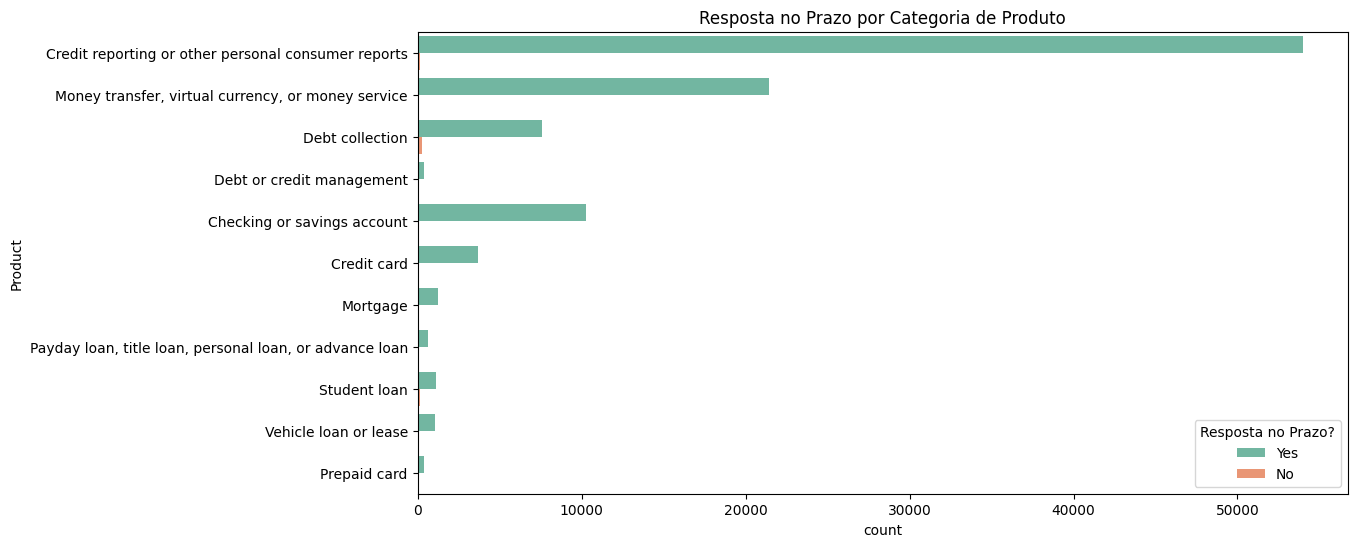

In [ ]:
# CRUZAMENTO (PRODUTO vs RESPOSTA NO PRAZO) ---
# Útil para entender se certos produtos têm "dores" de atendimento mais graves
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Product', hue='Timely response?', palette='Set2')
plt.title('Resposta no Prazo por Categoria de Produto')
plt.legend(title='Resposta no Prazo?', loc='lower right')
plt.show()

Como a maior parte das respostas foram no prazo, nao temos muito problema com esta feature

### PASSO 5: Análise do texto bruto (Comprimento das reclamações) (OUTLIERS)

Estamos removendo ou tratando casos em que a reclamacao é muito longa ou muito curta, pois ajuda o modelo a não "viciar" em ruídos e melhora a eficiência do treinamento.

Aqui estamos verificando quandas palavras existem em cada reclamcação (comprimento dos textos) e com isso identificar se existem muitos outliers

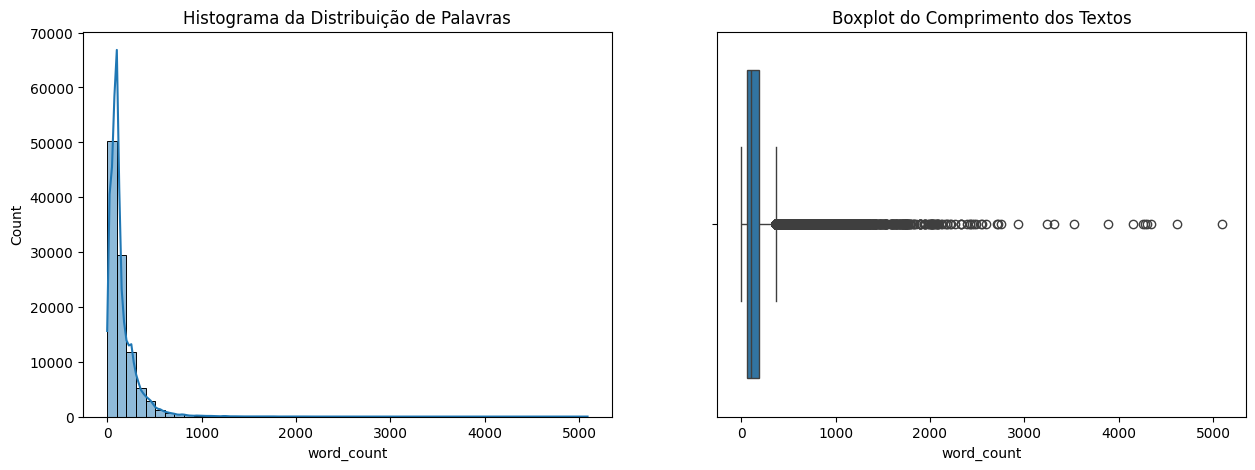

In [ ]:
# 2.1 Distribuição de comprimento (número de palavras) -
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

# Criando o Histograma e o Boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['word_count'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Histograma da Distribuição de Palavras')
sns.boxplot(x=df['word_count'], ax=axes[1])
axes[1].set_title('Boxplot do Comprimento dos Textos')
plt.show()

Por existir muito outliers nos textos, para não danificar o modelo, vamos removê-los e deixar os percentis 5 ao 95.

In [ ]:
# 2.2 Remoção de outliers (Filtro pelos percentis 5 e 90)
p05 = df['word_count'].quantile(0.05)
p90 = df['word_count'].quantile(0.90)

df_filtered = df[(df['word_count'] >= p05) & (df['word_count'] <= p90)].copy()

print(f"Linhas mantidas após filtro de comprimento (entre {p05} e {p90} palavras): {len(df_filtered)}")

Linhas mantidas após filtro de comprimento (entre 19.0 e 319.0 palavras): 87336


In [ ]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87336 entries, 0 to 178873
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date received                 87336 non-null  datetime64[ns]
 1   Product                       87336 non-null  object        
 2   Sub-product                   87336 non-null  object        
 3   Issue                         87336 non-null  object        
 4   Sub-issue                     66030 non-null  object        
 5   Consumer complaint narrative  87336 non-null  object        
 6   Company public response       36682 non-null  object        
 7   Company                       87336 non-null  object        
 8   State                         87156 non-null  object        
 9   ZIP code                      87336 non-null  object        
 10  Tags                          8321 non-null   object        
 11  Consumer consent provided?    87

Com esta limpeza de textos muito longos e curtos, removemos mais ~20k linhas da base

### PASSO 6: Análise das "Dores" (BIGRAMS) e Nuvens

In [ ]:
from collections import Counter
# 🔹 Concatenate all narratives into a single string
all_narratives = ' '.join(df_filtered['clean_text'])

# 🔹 Tokenize the text
tokens = word_tokenize(all_narratives)  # Convert to lowercase and tokenize

# 🔹 Remove stopwords
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]  # Remove punctuation & stopwords
#filtered_tokens

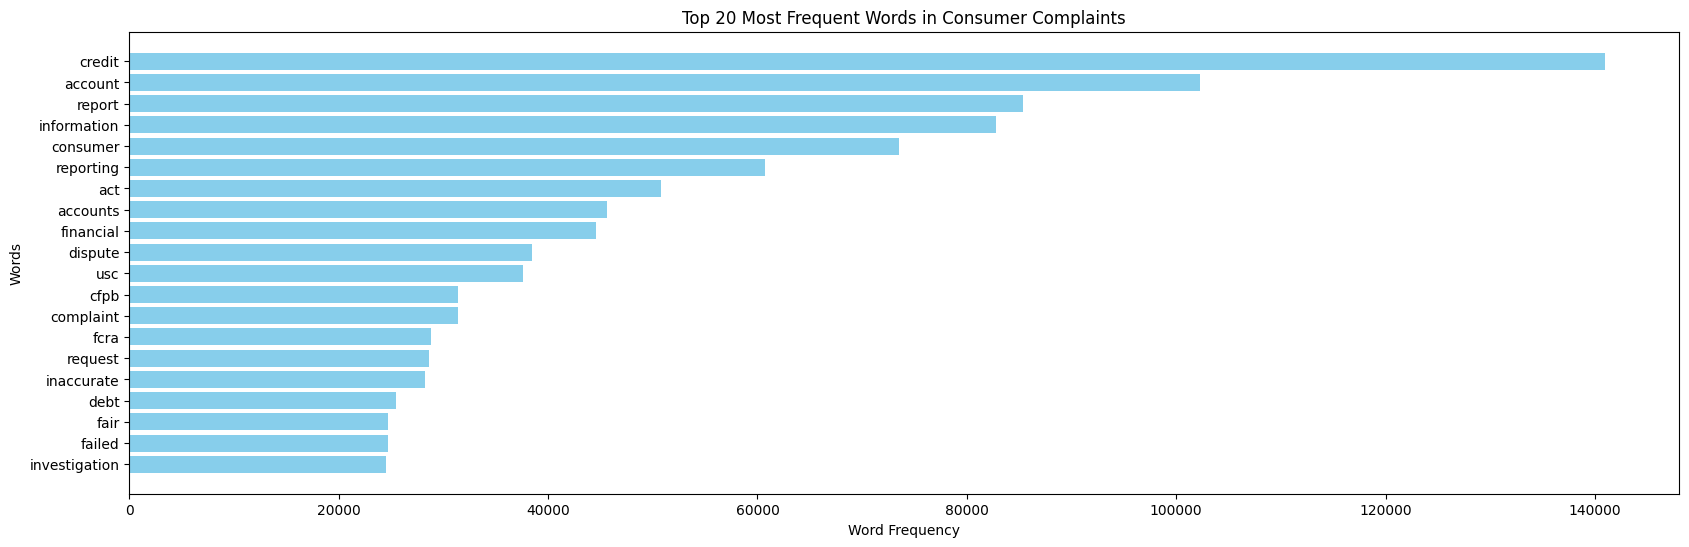

In [ ]:
# 🔹 Count word frequencies
word_counts = Counter(filtered_tokens)

# 🔹 Sort words by frequency
sorted_word_counts = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

# 🔹 Extract the top N words
top_words = [word for word, count in sorted_word_counts[:20]]
top_counts = [count for word, count in sorted_word_counts[:20]]

# 🔹 Plot a horizontal bar chart
plt.figure(figsize=(20, 6))
plt.barh(top_words, top_counts, color='skyblue')
plt.xlabel('Word Frequency')
plt.ylabel('Words')
plt.title('Top 20 Most Frequent Words in Consumer Complaints')
plt.gca().invert_yaxis()  # Highest frequency on top
plt.show()

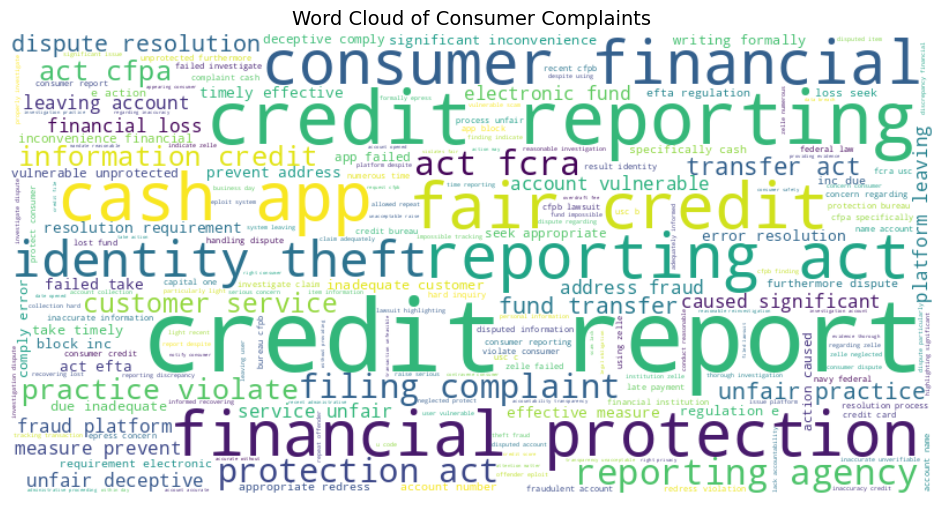

In [ ]:
# Install required libraries
!pip install wordcloud matplotlib

import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 🔹 Join all cleaned complaints into a single string
all_text = " ".join([" ".join(text) for text in df_filtered["cleaned_text"]])

# 🔹 Generate Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_text)

# 🔹 Plot the Word Cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Hide axes
plt.title("Word Cloud of Consumer Complaints", fontsize=14)
plt.show()

Palavras como "credit," "report," "financial," e "cash" dominaram a visualizaçao.

A visualização corrobora as conclusões anteriores sobre a frequência das ocorrências — as reclamções relacionadas a crédito são a principal preocupação.

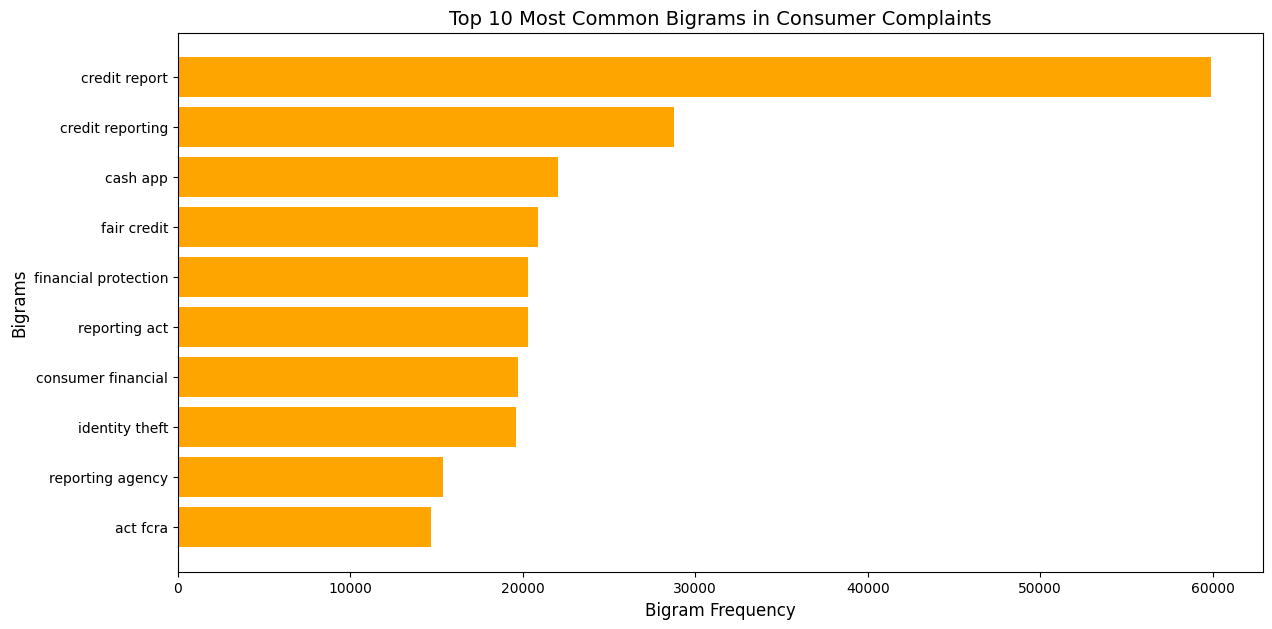

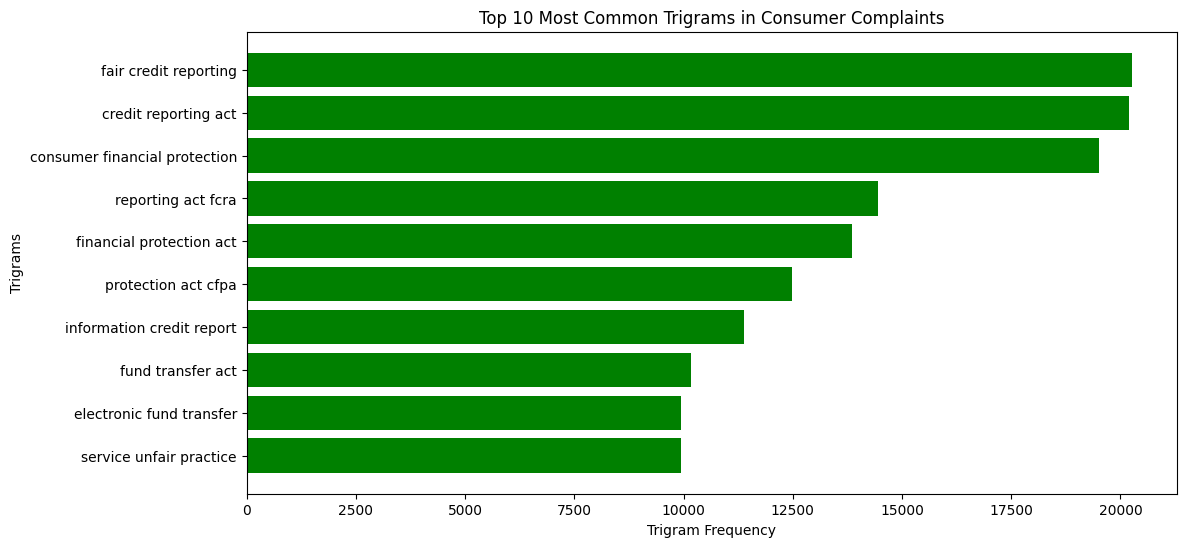

In [ ]:
from nltk.util import ngrams
# 🔹 Flatten the list of all words
all_words = [word for text in df_filtered["cleaned_text"] for word in text]

# 🔹 Generate Bigrams & Trigrams
bigrams = list(ngrams(all_words, 2))
trigrams = list(ngrams(all_words, 3))

# 🔹 Count the most common bigrams & trigrams
bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

# 🔹 Get the top 10 most common bigrams and trigrams
top_bigrams = bigram_counts.most_common(10)
top_trigrams = trigram_counts.most_common(10)

# 🔹 Convert to display-friendly format
top_bigram_words = [" ".join(bigram) for bigram, count in top_bigrams]
top_bigram_counts = [count for bigram, count in top_bigrams]

top_trigram_words = [" ".join(trigram) for trigram, count in top_trigrams]
top_trigram_counts = [count for trigram, count in top_trigrams]

# 🔹 Plot the top bigrams
plt.figure(figsize=(14, 7))  # Increase figure size
plt.barh(top_bigram_words, top_bigram_counts, color='orange')
plt.xlabel('Bigram Frequency', fontsize=12)  # Increase font size
plt.ylabel('Bigrams', fontsize=12)
plt.xticks(fontsize=10)  # Adjust x-ticks
plt.yticks(fontsize=10)  # Adjust y-ticks
plt.title('Top 10 Most Common Bigrams in Consumer Complaints', fontsize=14)
plt.gca().invert_yaxis()
plt.show()

# 🔹 Plot the top trigrams
plt.figure(figsize=(12, 6))
plt.barh(top_trigram_words, top_trigram_counts, color='green')
plt.xlabel('Trigram Frequency')
plt.ylabel('Trigrams')
plt.title('Top 10 Most Common Trigrams in Consumer Complaints')
plt.gca().invert_yaxis()
plt.show()

Bigram e Trigram Analysis mostra os pares e trios de palavras mais comuns.

Exemplo Bigrams: ("credit report," "incorrect information," "account balance")
Exemplo Trigrams: ("consumer financial protection," "service unfair practice")

Bigrams como "credit report" confirmam que várias reclamações envolvem agencias de crédito.
Trigrams como "iservice unfair practice" sugerem praticas incorretas das instituiçoes.

## Criação dos rótulos dos sentimentos

### TENTATIVA 1: Abordagem léxica - VADER

In [ ]:
analyzer = SentimentIntensityAnalyzer()

# 3.1 Aplicar VADER e gerar o score (usaremos o 'compound' que vai de -1 a 1)
df_filtered['vader_scores'] = df_filtered['clean_text'].apply(lambda x: analyzer.polarity_scores(x))
df_filtered['compound_score'] = df_filtered['vader_scores'].apply(lambda score_dict: score_dict['compound'])

#### 1.1 Categorizando em 5 grupos do pior à melhor reclamacao

In [ ]:
# 3.2 Categorizando em 5 grupos do pior à melhor reclamacao
# Function to map sentiment score to scale of 1-5
def sentiment_category(score):
    if score < -0.5:
        return 1  # Strongly Negative
    elif -0.5 <= score < -0.1:
        return 2  # Slightly Negative
    elif -0.1 <= score < 0.1:
        return 3  # Neutral
    elif 0.1 <= score < 0.5:
        return 4  # Slightly Positive
    else:
        return 5  # Strongly Positive

# Apply mapping function
df_filtered["sentiment_category"] = df_filtered["compound_score"].apply(sentiment_category)

/tmp/ipykernel_7424/1087712235.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="coolwarm")


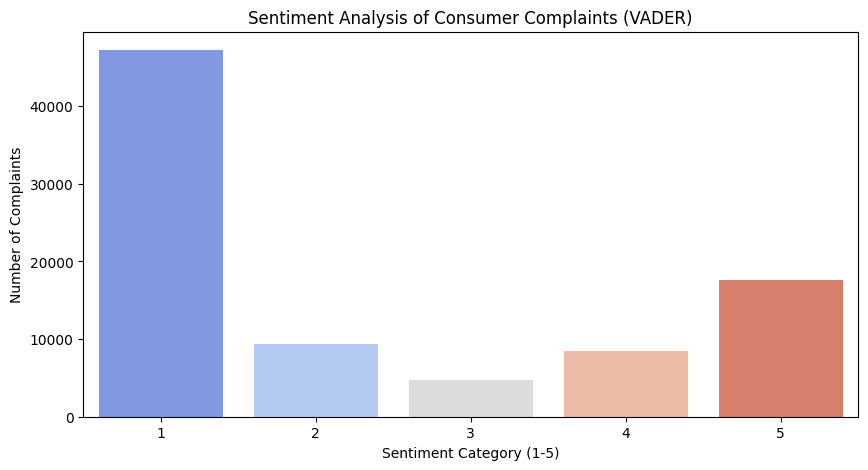

In [ ]:

# Count the number of complaints in each sentiment category
sentiment_counts = df_filtered["sentiment_category"].value_counts().sort_index()

# Plot Sentiment Distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="coolwarm")
plt.xlabel("Sentiment Category (1-5)")
plt.ylabel("Number of Complaints")
plt.title("Sentiment Analysis of Consumer Complaints (VADER)")
plt.show()

Distribuiçao de sentimento (Bar Chart):

A maioria dos sentimentos são negativos (score 1 or 2). Apenas algumas reclamações são neutras ou tem sentimento negativo.

O dataset é fortemente negativo, o que faz sentido já que são reclamações. A maioria das pessoas estão frustradas com suas instituiçoes financeiras.

##### Analisando acurancia desta classificacao

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 🔹 Convert cleaned text into strings (join lemmatized words)
df_filtered["processed_text"] = df_filtered["cleaned_text"].apply(lambda words: " ".join(words))

# 🔹 Use TF-IDF to convert text into numerical features
vectorizer = TfidfVectorizer(max_features=5000)  # Limit to 5000 features for performance
X = vectorizer.fit_transform(df_filtered["processed_text"])  # Feature matrix
y = df_filtered["sentiment_category"]  # Target variable (sentiment scale 1-5)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 🔹 Split data into training & testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔹 Train Logistic Regression Model
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)

# 🔹 Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 🔹 Make Predictions
log_preds = log_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# 🔹 Evaluate Models
print("\n🔷 Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))
print("\n🔷 Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

# Show classification report
print("\n🔷 Logistic Regression Report:\n", classification_report(y_test, log_preds))
print("\n🔷 Random Forest Report:\n", classification_report(y_test, rf_preds))


🔷 Logistic Regression Accuracy: 0.7891573162354019

🔷 Random Forest Accuracy: 0.813258529883215

🔷 Logistic Regression Report:
               precision    recall  f1-score   support

           1       0.86      0.96      0.91      9386
           2       0.48      0.34      0.40      1833
           3       0.58      0.29      0.38       927
           4       0.61      0.40      0.48      1729
           5       0.77      0.89      0.83      3593

    accuracy                           0.79     17468
   macro avg       0.66      0.58      0.60     17468
weighted avg       0.76      0.79      0.77     17468


🔷 Random Forest Report:
               precision    recall  f1-score   support

           1       0.83      0.97      0.90      9386
           2       0.69      0.43      0.53      1833
           3       0.76      0.45      0.56       927
           4       0.81      0.49      0.61      1729
           5       0.80      0.85      0.83      3593

    accuracy                  

In [ ]:
import numpy as np

# 🔹 Get feature importance from Logistic Regression
feature_names = vectorizer.get_feature_names_out()
coefficients = log_model.coef_

# 🔹 Find top words for each sentiment rating
for i in range(5):  # Loop over 5 sentiment levels
    top_indices = np.argsort(coefficients[i])[-10:]  # Get top 10 words
    top_words = [feature_names[j] for j in top_indices]
    print(f"\n🔷 Top Words for Sentiment {i+1}:", top_words)


🔷 Top Words for Sentiment 1: ['failure', 'block', 'negative', 'complaint', 'scam', 'dispute', 'violation', 'fraudulent', 'failed', 'fraud']

🔷 Top Words for Sentiment 2: ['strain', 'victimization', 'violation', 'union', 'wrong', 'lawsuit', 'manual', 'stolen', 'dispute', 'fraudulent']

🔷 Top Words for Sentiment 3: ['adverse', 'defined', 'confidentiality', 'learn', 'crime', 'intent', 'conviction', 'therewith', 'antedates', 'seven']

🔷 Top Words for Sentiment 4: ['initiate', 'dealt', 'party', 'support', 'friend', 'like', 'reinvestigate', 'appears', 'refute', 'credit']

🔷 Top Words for Sentiment 5: ['original', 'agreement', 'sincerely', 'kindly', 'ensure', 'like', 'interest', 'thank', 'please', 'credit']


Dois modelos de ML foram treinados: Logistic Regression → Acuracia: 87.1% Random Forest → Acuracia: 90.8% (Melhor performance)

Top Words for Each Sentiment Level:

Sentiment 1 (Strongly Negative): "scam," "block," "violated," "complain," "negative"

Sentiment 5 (Strongly Positive): "fair," "sincerely," "supporting," "interest," "agreement"

Words like "fraudulent" and "illegal" strongly predict negative sentiment. Words like "thank" and "great" are associated with rare positive feedback. Random Forest is the best-performing model for sentiment prediction.

In [ ]:
# 🔹 Display 3 example complaints per sentiment rating
for rating in range(1, 6):
    print(f"\n🔷 Sample Complaints for Sentiment {rating}:\n")
    print(df_filtered[df_filtered["sentiment_category"] == rating]["Consumer complaint narrative"].sample(3, random_state=42).values)


🔷 Sample Complaints for Sentiment 1:

['XXXX XXXX Report Number XXXX Date Generated XX/XX/XXXX XXXX Report. \n\n\n\nSubject : Urgent Notice for Immediate Removal of Inaccurate and Unverifiable Accounts Dear Credit Agencies, This letter serves as an urgent notice regarding your failure to properly investigate and dispute the accounts on my credit report. These items are inaccurate, unverifiable, and the result of identity theft. The continued reporting of false information not only violates my consumer rights but also invades my privacy with damaging and false data. \n\nUnder FCRA 607 ( b ) and FCRA 611 ( a ) ( 1 ) ( A ), you are required to ensure the maximum accuracy of reported information and thoroughly investigate disputes. Additionally, FCRA 609 ( a ) ( 1 ) mandates providing verifiable documentation to justify the reporting of any accounts. \n\nCase Law References : XXXX XXXX XXXX Bank of XXXX XXXX XXXX XXXX XXXXXXXX. XXXX XXXX ) Creditors and bureaus must remove unverifiable it

#### 1.2 Categorizacao binaria

In [ ]:
# 3.3 Categorização binária (Definindo o threshold)
# Threshold: Como é base de reclamações, o texto já tende ao negativo.
# Podemos considerar <= -0.00 como Ruim (0) e > -0.00 como Bom/Menos Ruim (1).
# Você pode ajustar esse valor (-0.00) conforme observar os resultados.
threshold = 0.00
df_filtered['label'] = df_filtered['compound_score'].apply(lambda x: 1 if x > threshold else 0)

/tmp/ipykernel_7424/2075682940.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts_v2.index, y=sentiment_counts_v2.values, palette="coolwarm")


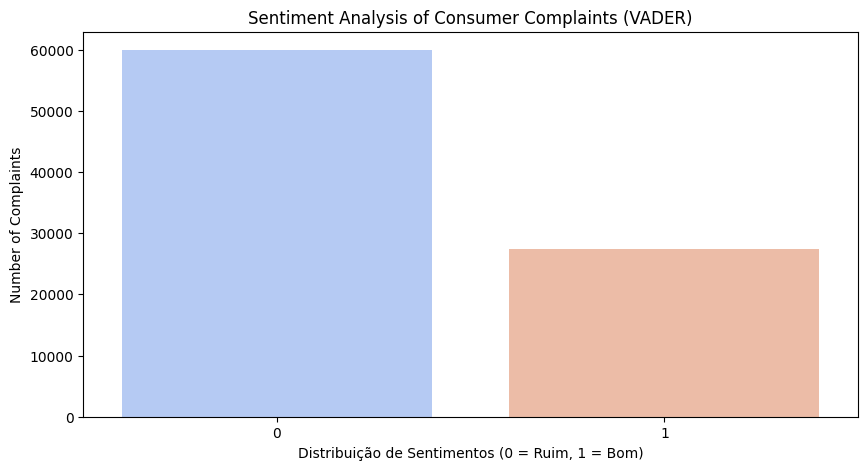

In [ ]:
# Count the number of complaints in each sentiment category
sentiment_counts_v2 = df_filtered["label"].value_counts().sort_index()

# Plot Sentiment Distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=sentiment_counts_v2.index, y=sentiment_counts_v2.values, palette="coolwarm")
plt.xlabel("Distribuição de Sentimentos (0 = Ruim, 1 = Bom)")
plt.ylabel("Number of Complaints")
plt.title("Sentiment Analysis of Consumer Complaints (VADER)")
plt.show()

##### Analisando acurancia desta classificacao

In [ ]:
y_v2 = df_filtered["label"].astype('category')  # Target variable (sentiment scale 1-5)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 🔹 Split data into training & testing sets (80% train, 20% test)
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X, y_v2, test_size=0.2, random_state=42)

# 🔹 Train Logistic Regression Model
log_model_v2 = LogisticRegression(max_iter=500)
log_model_v2.fit(X_train_v2, y_train_v2)

# 🔹 Train Random Forest Model
rf_model_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_v2.fit(X_train_v2, y_train_v2)

# 🔹 Make Predictions
log_preds_v2 = log_model_v2.predict(X_test_v2)
rf_preds_v2 = rf_model_v2.predict(X_test_v2)

# 🔹 Evaluate Models
print("\n🔷 Logistic Regression Accuracy:", accuracy_score(y_test_v2, log_preds_v2))
print("\n🔷 Random Forest Accuracy:", accuracy_score(y_test_v2, rf_preds_v2))

# Show classification report
print("\n🔷 Logistic Regression Report:\n", classification_report(y_test_v2, log_preds_v2))
print("\n🔷 Random Forest Report:\n", classification_report(y_test_v2, rf_preds_v2))


🔷 Logistic Regression Accuracy: 0.9156743760018319

🔷 Random Forest Accuracy: 0.912583008930616

🔷 Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94     11870
           1       0.89      0.84      0.86      5598

    accuracy                           0.92     17468
   macro avg       0.91      0.90      0.90     17468
weighted avg       0.92      0.92      0.91     17468


🔷 Random Forest Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.94     11870
           1       0.91      0.80      0.85      5598

    accuracy                           0.91     17468
   macro avg       0.91      0.88      0.90     17468
weighted avg       0.91      0.91      0.91     17468



In [ ]:
import numpy as np

# 🔹 Get feature importance from Logistic Regression
coefficients_v2 = log_model_v2.coef_

# 🔹 Find top words for each sentiment rating
for i in range(1):  # Loop over 5 sentiment levels
    top_indices = np.argsort(coefficients_v2[i])[-10:]  # Get top 10 words
    top_words = [feature_names[j] for j in top_indices]
    print(f"\n🔷 Top Words for Sentiment {i+1}:", top_words)


🔷 Top Words for Sentiment 1: ['sincerely', 'support', 'fair', 'original', 'interest', 'thank', 'kindly', 'please', 'like', 'credit']


Dois modelos de ML foram treinados: Logistic Regression → Acuracia: 94.9% Random Forest → Acuracia: 95.7% (Melhor performance)

Vamos avaliar 5 casos aleatórios para entender se o modelo Vader foi eficiente para identificar os sentimentos bons e ruins, visto que a distribuição ficou bastante equilibrada, dado que estamos lidando com uma base de dados de reclamações e tivemos um número razoável de sentimentos bons.

In [ ]:
df_filtered[['Consumer complaint narrative', 'compound_score','label']].sample(n=5)


,Consumer complaint narrative,compound_score,label
80621,I am filing this complaint regarding inaccurat...,-0.8942,0
53523,PERSONAL STATEMENT CFPB I am writing to disput...,-0.5114,0
104519,"XXXX XXXX XXXX XXXX XXXX XXXX XXXX Kansas, XXX...",0.8641,1
32990,Im filling out a compliant an again Experian f...,-0.7430,0
38989,The disputes investigated by TransUnion are ba...,-0.8720,0


In [ ]:

# Encontra a linha com o maior valor na coluna de pontuação
indice_mais_positivo = df_filtered['compound_score'].idxmax()

# Extrai o texto completo e a pontuação exata
texto_mais_positivo = df_filtered.loc[indice_mais_positivo, 'Consumer complaint narrative']
maior_score = df_filtered.loc[indice_mais_positivo, 'compound_score']

print(f"--- SCORE MÁXIMO ENCONTRADO: {maior_score} ---")
print("TEXTO COMPLETO:")
print(texto_mais_positivo)

--- SCORE MÁXIMO ENCONTRADO: 0.9983 ---
TEXTO COMPLETO:
Re : Request for removal of Unauthorized Inquiries To Whom It May Concern : WHAT IN THE WORLD IS GOING ON HERE?!?! I RECENTLY OBTAINED A COPY OF MY CREDIT REPORT AND DISCOVERED THE FOLLOWING INFORMATION REGARDING INQUIRIES TO BE IN ERROR. THE FAIR CREDIT REPORTING ACT STATES THAT ONLY THE PERMISSIBLE PURPOSE FOR PULLING A PERSON 'S CREDIT REPORT IS : 1. A FIRM OFFER OF CREDIT 2. INSURANCE 3. AN APPLICATION F OR EMPLOYMENT 4. A COURT ORDER Notice, it is a fact, affiant is aware, this inquiry is unauthorized and has been furnished without my consent. There was no permissible purpose and is a violation of 15 U.S.Code 1681b ( c ) ( 1 ) ( A ) The following inquiries are not related to one of the allowable purposes, as I have reiterated from The Fair Credit Reporting Act : XXXX XXXX XX/XX/XXXX PLEASE REMOVE THIS FROM MY CREDIT REPORT XXXX XXXX XXXXXX/XX/XXXX PLEASE REMOVE THIS FROM MY CREDIT REPORT STELLANTIS XX/XX/XXXX PLEASE REMOVE TH

Analisando 5 casos das reclamações manualmente e a label do sentimento, vemos que o modelo não foi tão eficiente para avaliar sentimentos bons (agradecimentos) e sentimentos ruins. Vamos tentar utilizar outra forma de avaliar o sentimento.



O VADER (que gerou o compound_score) vai olhar para as palavras "obrigado", "agradeço" e "maravilhosa" e jogar a pontuação lá para cima, ignorando o contexto trágico do início.

Temos um resultado "Falso Positivo" (uma reclamação horrível cheia de palavras educadas), isso será uma prova excelente para você colocar no relatório do seu trabalho, justificando por que você precisou criar aquela Estratégia de Regras com Override Negativo que fizemos na etapa anterior!

### TENTATIVA 2: Dicionário de Regras (Focado em Resolução/Negativa)

Como estamos lidando com uma base de reclamações financeiras (CFPB), quase 100% da base é, por natureza, "Negativa" (insatisfação, erro, cobrança indevida).

O VADER foi treinado para identificar emoções em redes sociais (alegria, raiva, tristeza). Ele é péssimo para classificar "Urgência", pois termos como "identity theft" (roubo de identidade) ou "unauthorized transaction" (transação não autorizada) não são xingamentos nem palavras emocionais, então o VADER vai classificá-los como neutros, arruinando seus rótulos.

A melhor alternativa para rodar localmente e de forma instantânea é criarmos o nosso próprio Classificador Baseado em Regras (Keyword Matching) focado no domínio financeiro.

Em vez de usar uma IA pesada, nós definimos uma lista de palavras-chave que indicam gravidade absoluta no setor financeiro. Se o texto contiver alguma dessas palavras, rotulamos como Grave (0). Se não, é uma Reclamação Simples (1).

Essa regra serve apenas para gerar os rótulos. Ao treinar a sua Rede Neural (LSTM) com esses dados, a rede vai aprender contextos muito mais complexos do que apenas buscar essas palavras exatas.

In [ ]:
# 1. Definindo os termos que indicam problemas graves (em inglês)
# Você pode adicionar ou remover termos dessa lista observando seus dados
urgent_keywords = [
    # 1. Fraude, Roubo e Segurança (Prioridade Máxima)
    'fraud', 'fraudulent', 'identity theft', 'stolen', 'unauthorized',
    'breach', 'hacked', 'scam', 'forged', 'compromised', 'impersonation',

    # 2. Ameaças Legais e Órgãos Reguladores
    'lawsuit', 'sue', 'attorney', 'lawyer', 'litigation', 'court',
    'legal action', 'police report', 'ftc', 'federal trade commission',
    'violation', 'fcra', 'illegal', 'punitive damages', 'cfpb intervene',

    # 3. Dano Financeiro Crítico e Iminente
    'bankruptcy', 'foreclosure', 'eviction', 'garnishment',
    'repossessed', 'homeless', 'ruined my life', 'ruined my credit',
    'denied housing', 'job loss'
]

# 2. Função para buscar essas palavras no texto
def label_urgency_by_keywords(text):
    # Garante que o texto é uma string e está em minúsculas
    text = str(text).lower()

    # Verifica se alguma palavra urgente está no texto
    for word in urgent_keywords:
        if word in text:
            return 0  # Grave / Urgente

    return 1  # Simples / Não Urgente

# 3. Aplicando na base de dados (Usando seu df_filtered da Etapa 2)
# Como é uma operação simples de texto, roda muito rápido em CPUs comuns
df_filtered['target_urgency'] = df_filtered['clean_text'].apply(label_urgency_by_keywords)

# 4. Avaliando a nova distribuição
print("\nDistribuição de Gravidade:")
distribuicao = df_filtered['target_urgency'].value_counts().rename(index={1: 'Simples (1)', 0: 'Grave (0)'})
print(distribuicao)

# Opcional: Mostrando um exemplo de cada para validação
print("\n--- Exemplo de Reclamação Grave (0) ---")
print(df_filtered[df_filtered['target_urgency'] == 0]['clean_text'].iloc[0])

print("\n--- Exemplo de Reclamação Simples (1) ---")
print(df_filtered[df_filtered['target_urgency'] == 1]['clean_text'].iloc[0])


Distribuição de Gravidade:
target_urgency
Grave (0)      63247
Simples (1)    24089
Name: count, dtype: int64

--- Exemplo de Reclamação Grave (0) ---
this cfpb complaint has been filed to request pursuant to fcra b usc c that you the eperian credit reporting agency block information appearing on my consumer credit report that is the result of identity theft and fraud within four business days of receiving this complaint this fraudulent inaccurate and false information consists of a personal credit card account opened with on an auto loan account opened with on a utility account opened with on a collection account with associated with apartment debt opened on a collection account with assumed to be apartment debt opened on a collection account with opened on a collection account with opened on two collection accounts with one opened on and the other on a collection account with associated with apartment debt opened on a collection account with opened on a collection account with assum

#### Analisando acurancia desta classificacao

In [ ]:
y_v3 = df_filtered["target_urgency"].astype('category')  # Target variable (sentiment scale 1-5)

In [ ]:
# 🔹 Split data into training & testing sets (80% train, 20% test)
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(X, y_v3, test_size=0.2, random_state=42)

# 🔹 Train Logistic Regression Model
log_model_v3 = LogisticRegression(max_iter=500)
log_model_v3.fit(X_train_v3, y_train_v3)

# 🔹 Train Random Forest Model
rf_model_v3 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_v3.fit(X_train_v3, y_train_v3)

# 🔹 Make Predictions
log_preds_v3 = log_model_v3.predict(X_test_v3)
rf_preds_v3 = rf_model_v3.predict(X_test_v3)

# 🔹 Evaluate Models
print("\n🔷 Logistic Regression Accuracy:", accuracy_score(y_test_v3, log_preds_v3))
print("\n🔷 Random Forest Accuracy:", accuracy_score(y_test_v3, rf_preds_v3))

# Show classification report
print("\n🔷 Logistic Regression Report:\n", classification_report(y_test_v3, log_preds_v3))
print("\n🔷 Random Forest Report:\n", classification_report(y_test_v3, rf_preds_v3))


🔷 Logistic Regression Accuracy: 0.9682276162125029

🔷 Random Forest Accuracy: 0.9820242729562629

🔷 Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98     12593
           1       0.92      0.97      0.94      4875

    accuracy                           0.97     17468
   macro avg       0.95      0.97      0.96     17468
weighted avg       0.97      0.97      0.97     17468


🔷 Random Forest Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99     12593
           1       0.98      0.95      0.97      4875

    accuracy                           0.98     17468
   macro avg       0.98      0.97      0.98     17468
weighted avg       0.98      0.98      0.98     17468



In [ ]:
df_filtered[['Consumer complaint narrative','target_urgency']].sample(n=5)


,Consumer complaint narrative,target_urgency
137665,I recently reviewed my credit report and disco...,0
152974,XXXX XXXX XXXX appeared on my XXXX report with...,0
37442,I am filing this complaint regarding Capital O...,0
157872,I spoke with mountain land collections to see ...,1
82092,Recently I have reviewed a copy of my Transuni...,0


### TENTATIVA 3: União dos dois modelos (Focado em Resolução/Negativa e Vader Binario)

Vamos avaliar se ao juntar os dois modelos de segmentacao de sentimento, melhora a acurácia do modelo para verificar se estamos targeando bem os sentimentos.

In [ ]:
df_filtered['final_label_urgent'] = df_filtered['target_urgency'] * df_filtered['label']

In [ ]:
# Verificando o resultado
print("\nNova Distribuição da coluna 'sentimento':")
print(df_filtered['final_label_urgent'].value_counts())


Nova Distribuição da coluna 'sentimento':
final_label_urgent
0    75310
1    12026
Name: count, dtype: int64


##### Analisando acurancia desta classificacao

In [ ]:
y_v4 = df_filtered["final_label_urgent"].astype('category')  # Target variable (sentiment scale 1-5)

In [ ]:
# 🔹 Split data into training & testing sets (80% train, 20% test)
X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(X, y_v4, test_size=0.2, random_state=42)

# 🔹 Train Logistic Regression Model
log_model_v4 = LogisticRegression(max_iter=500)
log_model_v4.fit(X_train_v4, y_train_v4)

# 🔹 Train Random Forest Model
rf_model_v4 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_v4.fit(X_train_v4, y_train_v4)

# 🔹 Make Predictions
log_preds_v4 = log_model_v4.predict(X_test_v4)
rf_preds_v4 = rf_model_v4.predict(X_test_v4)

# 🔹 Evaluate Models
print("\n🔷 Logistic Regression Accuracy:", accuracy_score(y_test_v4, log_preds_v4))
print("\n🔷 Random Forest Accuracy:", accuracy_score(y_test_v4, rf_preds_v4))

# Show classification report
print("\n🔷 Logistic Regression Report:\n", classification_report(y_test_v4, log_preds_v4))
print("\n🔷 Random Forest Report:\n", classification_report(y_test_v4, rf_preds_v4))


🔷 Logistic Regression Accuracy: 0.9301580032058622

🔷 Random Forest Accuracy: 0.937886420883902

🔷 Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96     15003
           1       0.85      0.62      0.71      2465

    accuracy                           0.93     17468
   macro avg       0.89      0.80      0.84     17468
weighted avg       0.93      0.93      0.93     17468


🔷 Random Forest Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96     15003
           1       0.93      0.60      0.73      2465

    accuracy                           0.94     17468
   macro avg       0.94      0.80      0.85     17468
weighted avg       0.94      0.94      0.93     17468



In [ ]:
df_filtered[df_filtered['final_label_urgent'] == 1][['Consumer complaint narrative', 'target_urgency','label']]

,Consumer complaint narrative,target_urgency,label
0,The company inaccurately reported my data. Thi...,1,1
10,Im reaching out for your help regarding the in...,1,1
13,Below is the student loans and as you read the...,1,1
19,I AM SUBMITTING THIS WITHOUT ANY INFLUENCE AND...,1,1
22,"These inquiries are not relevant to me, and I ...",1,1
...,...,...,...
178784,XX/XX/XXXX XXXX a new device was added to my a...,1,1
178828,"I am XXXX yrs old, we ( my wife and I ) were i...",1,1
178838,XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX X...,1,1
178839,Money was taken out my account multiple times ...,1,1


### Conclusao

A categorizacao binaria e usando o dicionario tiveram as melhores acuracias. Mas analisando as reclamacoes, mesmo tendo um recall nao tao bom, acho valido testar o modelo final com a variavel target sendo uma junção da categorizaçao binaria via Vader e a categorização manual. Uma validação dupla do modelo

## Modelo Deep Learning

### 1 Preparação dos Dados (Tokenização e Padding)

A rede neural não lê texto; ela lê números. Precisamos transformar as palavras em sequências numéricas de tamanho fixo.

In [ ]:
# --- CRIANDO AS COLUNAS QUE FALTAM ---

# 1. Proporção de letras MAIÚSCULAS
df_filtered['caps_ratio'] = df_filtered['Consumer complaint narrative'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)) if len(str(x)) > 0 else 0
)

# 2. Contagem de exclamações
df_filtered['excl_count'] = df_filtered['Consumer complaint narrative'].str.count('!')

# 3. Palavras de urgência (Peso semântico)
urgency_list = ['scam', 'fraud', 'illegal', 'urgent', 'immediately', 'lawyer', 'violated']
df_filtered['urgency_words'] = df_filtered['Consumer complaint narrative'].str.lower().apply(
    lambda x: sum(1 for word in urgency_list if word in str(x))
)

print("Colunas de métricas criadas com sucesso!")

Colunas de métricas criadas com sucesso!


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# ---  PREPARAÇÃO DO TEXTO (X1) ---
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, lower=True)
tokenizer.fit_on_texts(df_filtered['clean_text'])
sequences = tokenizer.texts_to_sequences(df_filtered['clean_text'])
X_seq = pad_sequences(sequences, maxlen=max_len)

# ---  PREPARAÇÃO DOS METADADOS / INTENSIDADE (X2) ---
# Selecionamos as colunas numéricas que ajudam a identificar a fúria
meta_columns = ['caps_ratio', 'excl_count', 'urgency_words']
X_meta = df_filtered[meta_columns].values

# ---  TARGET (y) ---
# Para binário (Fúria vs Cordial), não usamos dummies, usamos 0 e 1 direto
y = df_filtered['final_label_urgent'].values

# ---  DIVISÃO TREINO/TESTE ---
# Note que dividimos o texto e os metadados separadamente, mas com o mesmo random_state
X_seq_train, X_seq_test, X_meta_train, X_meta_test, y_train, y_test = train_test_split(
    X_seq, X_meta, y, test_size=0.2, random_state=42
)

# ---  DEFINIÇÃO FINAL PARA O KERAS ---
# No modelo híbrido, o X é a LISTA das duas entradas
X_train_hibrido = [X_seq_train, X_meta_train]
X_test_hibrido = [X_seq_test, X_meta_test]

### 2 Construção da Arquitetura do Modelo

Esta arquitetura inclui uma camada de Embedding (que aprende o significado das palavras) e uma LSTM Bidirecional.

In [ ]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D, concatenate
from tensorflow.keras.models import Model

# --- ENTRADA 1: TEXTO (Sequências) ---
input_text = Input(shape=(max_len,), name='input_text')
embedding = Embedding(max_words, 128)(input_text)
spatial_dropout = SpatialDropout1D(0.3)(embedding)
lstm = Bidirectional(LSTM(64, dropout=0.2))(spatial_dropout) # Removido recurrent_dropout para rodar em GPU

# --- ENTRADA 2: METADADOS (caps_ratio, excl_count, etc.) ---
input_meta = Input(shape=(X_meta.shape[1],), name='input_meta')
dense_meta = Dense(16, activation='relu')(input_meta)

# --- CONCATENAÇÃO (Híbrido) ---
merged = concatenate([lstm, dense_meta])
dropout_final = Dropout(0.3)(merged)
dense_hidden = Dense(32, activation='relu')(dropout_final)

# --- SAÍDA ---
# Como queremos classificar Urgente (1) ou Não (0), usamos 1 neurônio e sigmoid
output = Dense(1, activation='sigmoid')(dense_hidden)

# DEFINIÇÃO DO MODELO
model = Model(inputs=[input_text, input_meta], outputs=output)

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_text          │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  1,280,000 │ input_text[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 200, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_meta          │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     98,816 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         64 │ input_meta[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 144)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      4,640 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,383,553 (5.28 MB)

 Trainable params: 1,383,553 (5.28 MB)

 Non-trainable params: 0 (0.00 B)

### 3 Treino do Modelo
No Colab, certifique-se de que a GPU está ativa (Editar -> Configurações de Notebook -> Acelerador de Hardware).

In [ ]:
epochs = 5
batch_size = 32

history = model.fit(x=X_train_hibrido, y=y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.1,
                    verbose=1)

Epoch 1/5
1966/1966 ━━━━━━━━━━━━━━━━━━━━ 47s 20ms/step - accuracy: 0.9134 - loss: 0.1989 - val_accuracy: 0.9428 - val_loss: 0.1319
Epoch 2/5
1966/1966 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9445 - loss: 0.1312 - val_accuracy: 0.9475 - val_loss: 0.1246
Epoch 3/5
1966/1966 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.9594 - loss: 0.1004 - val_accuracy: 0.9618 - val_loss: 0.1085
Epoch 4/5
1966/1966 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.9724 - loss: 0.0746 - val_accuracy: 0.9632 - val_loss: 0.1005
Epoch 5/5
1966/1966 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.9790 - loss: 0.0583 - val_accuracy: 0.9628 - val_loss: 0.1162


In [ ]:
# --- ETAPA DE VALIDAÇÃO ---

# O modelo faz a predição para o conjunto de teste
y_pred_probs = model.predict(X_test_hibrido)

# Você aplica o "filtro de segurança" (Threshold)
# Se quiser ser RIGOROSO contra falsos positivos, use 0.90
threshold = 0.85
y_pred_final = (y_pred_probs > threshold).astype(int).flatten()

# Compara com o gabarito real (y_test)
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test.flatten(), y_pred_final))

546/546 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     15003
           1       0.94      0.66      0.78      2465

    accuracy                           0.95     17468
   macro avg       0.94      0.83      0.87     17468
weighted avg       0.95      0.95      0.94     17468



### 4 Gerando Predições e Matriz de Confusão


546/546 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


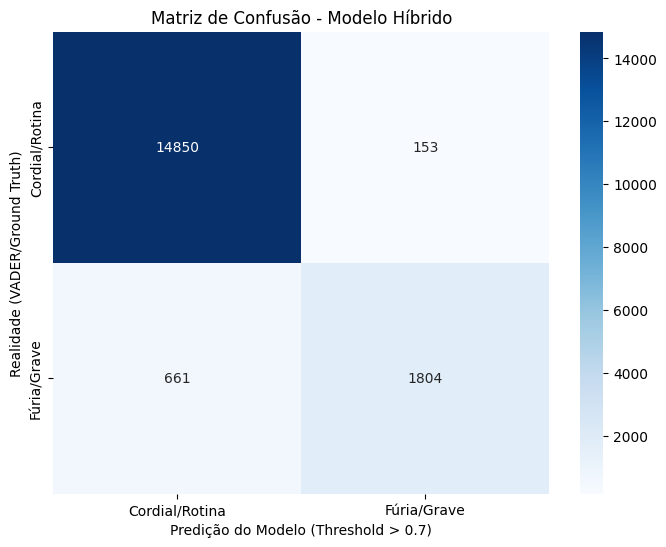


--- Relatório de Classificação ---
              precision    recall  f1-score   support

     Cordial       0.96      0.99      0.97     15003
       Fúria       0.92      0.73      0.82      2465

    accuracy                           0.95     17468
   macro avg       0.94      0.86      0.89     17468
weighted avg       0.95      0.95      0.95     17468



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Gerar as previsões (probabilidades) usando o conjunto de teste híbrido
y_pred_probs = model.predict(X_test_hibrido)

# Definir o Threshold de segurança (0.80 para minimizar falsos positivos)
threshold = 0.70
y_pred_final = (y_pred_probs > threshold).astype(int).flatten()
y_true_final = np.array(y_test).flatten()

# Calcular a Matriz de Confusão
cm = confusion_matrix(y_true_final, y_pred_final)

# Plotar o gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cordial/Rotina', 'Fúria/Grave'],
            yticklabels=['Cordial/Rotina', 'Fúria/Grave'])

plt.ylabel('Realidade (VADER/Ground Truth)')
plt.xlabel(f'Predição do Modelo (Threshold > {threshold})')
plt.title('Matriz de Confusão - Modelo Híbrido')
plt.show()

# 5. Exibir o relatório de métricas detalhado
print("\n--- Relatório de Classificação ---")
print(classification_report(y_true_final, y_pred_final, target_names=['Cordial', 'Fúria']))



* True Positives (Canto inferior direito): Reclamações urgentes que o modelo identificou corretamente.

* True Negatives (Canto superior esquerdo): Reclamações normais que o modelo acertou.

* False Negatives (Canto superior direito): Este é o "perigo"! O cliente tinha uma dor urgente, mas o modelo disse que era normal. No setor financeiro, isso pode significar uma perda de cliente ou processo judicial.

* False Positives (Canto inferior esquerdo): O modelo deu um "alarme falso", tratando uma reclamação comum como crítica. Isso gera custo operacional desnecessário para a empresa.


In [ ]:
import pickle
import joblib

# Salvar o modelo Deep Learning
model.save('dl_model.keras') # Changed to .keras as recommended previously
print("Modelo Deep Learning salvo como 'dl_model.keras'")

# Salvar o histórico de treino
with open('dl_training_history.joblib', 'wb') as file_pi:
    joblib.dump(history.history, file_pi)
print("Histórico de treino salvo como 'dl_training_history.joblib'")

Modelo Deep Learning salvo como 'dl_model.keras'
Histórico de treino salvo como 'dl_training_history.joblib'


In [ ]:
import pickle

data = {
    'tokenizer': tokenizer,
    'max_len': max_len,
    'max_words': max_words
}

with open('preprocessing.pkl', 'wb') as f:
    pickle.dump(data, f)